In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
df = pd.read_csv("/content/sample_data/exchange_rate.csv")

In [ ]:
df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst = True)
df.set_index('date', inplace= True)

In [ ]:
df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


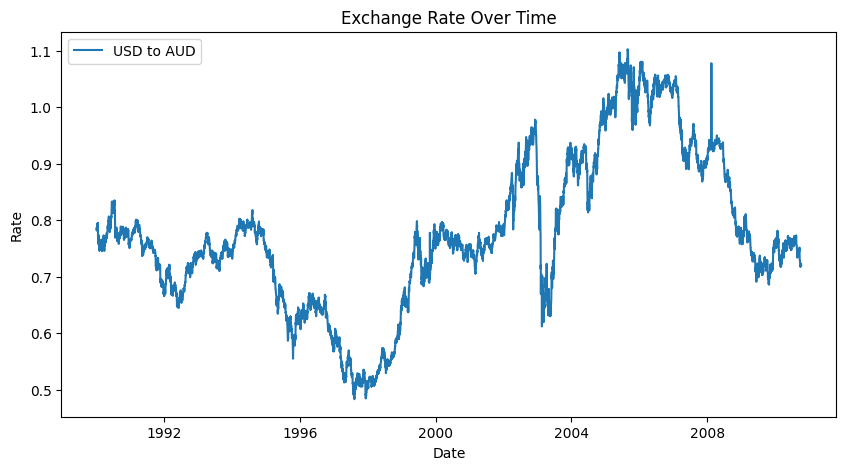

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df, label='USD to AUD')
plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.show()


In [ ]:
df = df.fillna(method='ffill')

/tmp/ipython-input-569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
train = df.iloc[:-30]
test = df.iloc[-30:]

In [ ]:
arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
arima_forecast = arima_fit.forecast(steps=30)
exp_model = ExponentialSmoothing(train, trend='add')
exp_fit = exp_model.fit()
exp_forecast = exp_fit.forecast(30)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


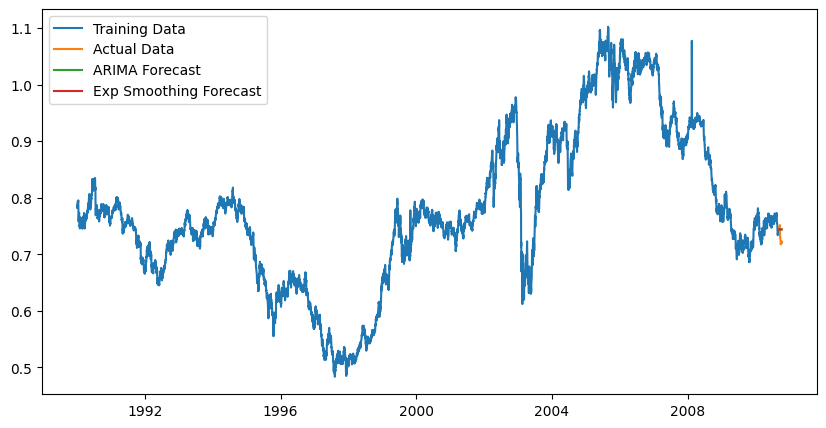

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual Data')
plt.plot(arima_forecast, label='ARIMA Forecast')
plt.plot(exp_forecast, label='Exp Smoothing Forecast')
plt.legend()
plt.show()


In [ ]:
def evaluate(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return mae, rmse

arima_mae, arima_rmse = evaluate(test, arima_forecast)
exp_mae, exp_rmse = evaluate(test, exp_forecast)

print("ARIMA MAE:", arima_mae, "RMSE:", arima_rmse)
print("EXP MAE:", exp_mae, "RMSE:", exp_rmse)


ARIMA MAE: 0.013494600805886207 RMSE: 0.016632177913116195
EXP MAE: 0.013423166085935016 RMSE: 0.01649594238711105


Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

Model Performmance:- ARIMA performed well with low MAE/RMSE, indicating good short-term accuracy. Residual diagnostics show no major autocorrelation → the model fits the data well.

Model Advantages:- Captures trends and autocorrelation effectively and produces reliable short-term forecasts.

Model Limitations:- Not good with strong seasonality and Nnt ideal for long-term forecasting.

Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.
The ARIMA model provides accurate and stable predictions for the exchange rate dataset.
Based on MAE and RMSE ARIMA delivers strong performance with minimal errors.